# Imports

The following modules are required to run this notebook:

In [1]:
# Custom modules
from src.cnn_manager import CNN_ResNet18
from src.dataset import DatasetCreator

# Data processing and visualization
import json
import random
import matplotlib.pyplot as plt
from PIL import Image

# File management
import shutil
import os

# Set directories

In [2]:
src_annotations = './data/_annotations.json'
src_raw_images = './data/raw/raw_images'
src_test_images = './data/raw/test_images'
src_models = './outputs/models'
src_plots = './outputs/plots'
classes_dir = './data/classes'

# 1. Auxiliary functions

The following auxiliary functions are helpfull to analize the model performance after the training process.

- Function used to plot the **validation accuracy** and **loss/cost** during the CNN training phase.

In [3]:
def plot_results(loss, accuracy, save=False, plot_name='train_results'):
    fig, ax1 = plt.subplots()

    # Plot loss
    color = 'tab:red'
    ax1.plot(loss, color=color)
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('LOSS', color=color)
    ax1.tick_params(axis='y', labelcolor=color)

    # Copy axis
    ax2 = ax1.twinx()

    # Plot accuracy
    color = 'tab:blue'
    ax2.plot(accuracy, color=color)
    ax2.set_ylabel('ACCURACY', color=color)
    ax2.tick_params(axis='y', labelcolor=color)

    # Adjust layout
    fig.tight_layout()

    if save:
        plt.savefig(os.path.join(src_plots, plot_name), dpi=300, bbox_inches="tight")
    
    plt.show()

- Function used to plot a sample image using **Pillow**.

In [4]:
def _imshow(path, title=''):
    image = Image.open(path).convert('RGB')
    plt.imshow(image)
    plt.title(title)
    plt.axis('off')
    plt.show()

# 2. Create folder structure

The following section creates a custom folder structure, neccessary to create the model datasets in the **section 3**.

```bash
classes/
├── class_1/
│   ├── images
├── class_2/
│   ├── images
```

For this project, an annotations JSON file was provided, containing the file names for each class. This file is used to create the folder structure.

Load annotations:

In [5]:
with open(src_annotations, 'r') as f:
    annotations = json.load(f)

print(annotations)

{'version': '1.0', 'type': 'classification', 'labels': ['not_stop', 'stop'], 'annotations': {'4d160925-f898-4364-8396-4992fbd76b71.jpg': [{'label': 'not_stop', 'id': 'ff23432e-85af-49eb-8612-f014844b2cf3'}], '7f8e60d4-e2ef-4145-b258-b128b808bd96.jpg': [{'label': 'not_stop', 'id': '251c7358-684f-42b6-8e71-b9ba7771381b'}], '60e51cce-96d5-4bb1-b748-299d2a9fc644.jpg': [{'label': 'not_stop', 'id': 'a20293b0-4671-4603-b5c1-348abfd1c468'}], 'e5b58fd6-68e7-41c6-ad6c-08c7563ac9d3.jpg': [{'label': 'not_stop', 'id': 'ced781ee-ccd8-41fb-827e-3366821d7e1e'}], 'c5e3624f-6b5a-4128-8eea-a57f4013c74b.jpg': [{'label': 'not_stop', 'id': '6eaf6fd8-4959-4e9e-a203-04e7df853708'}], 'eff7bd5e-0ee8-4b02-bf54-52b4e1eca781.jpg': [{'label': 'not_stop', 'id': '0d80cfdf-7e86-460a-8a0d-2750a7c28854'}], 'faba8d13-e92e-4bf9-ae6c-b7fb906572fa.jpg': [{'label': 'not_stop', 'id': '66a7a892-ad63-41dc-9c34-b17dad1285cc'}], 'd7ed0cdb-95fc-457d-b537-0b8311778004.jpg': [{'label': 'not_stop', 'id': 'be0e2860-4504-454b-b09a-72b6

Create label -> images list map:

In [6]:
label_to_images = {}

for file_name, label_list in annotations['annotations'].items():
    # Get label
    label = label_list[0]['label']
    # Store image name with corresponding label
    label_to_images.setdefault(label, []).append(file_name)

Create a **classes** folder, used to create the datasets:

In [7]:
for label, image_list in label_to_images.items():
    # Set class folder path
    folder_dir = os.path.join(classes_dir, label)
    # Create class folder
    os.makedirs(folder_dir, exist_ok=True)
    
    for file_name in image_list:
        # Set image src path
        src = os.path.join(src_raw_images, file_name)
        # Set destiny path
        dst = os.path.join(folder_dir, file_name)
        # Copy image to class folder
        shutil.copy2(src, dst)

print("Classes folder created successfully!")

Classes folder created successfully!


# 3. CNN

## 3.1 Create dataset

In [8]:
# Create instance
cnn = CNN_ResNet18()

# Create dataset
cnn.create_dataset(root=classes_dir)

Setting model as features extractor...
Replacing output layer...
Moving model to cpu...
Successfully created model.
----------------------------------------
DATASET CREATOR
Creating dataset...
Splitting dataset...
Train/Val split complete -> 90.00% training
177 train samples
20 validation samples
Transforming dataset...
Successfully created dataset
----------------------------------------
2 model classes: ['not_stop', 'stop']


Print CNN's hyper-parameters:

In [9]:
cnn.print_hypams()

Epochs: 10
Batch size: 32
Learning rate: 1e-06
Momentum: 0.9
Lr. scheduler: True
	Base lr: 1e-06
	Max lr: 0.001


## 3.2 Train

Steps performed by the `_train()` function:

1. **Initialize tracking variables:**
   
           - Set up lists to store training loss and validation accuracy per epoch.
           - Store initial model weights as the best model so far.

2. **Loop over epochs:**

           - For each epoch (iteration over the full training dataset)

***`TRAINING PHASE`***

3. **Loop over batches in train_loader:**

            - Move input data (x) and labels (y) to the appropriate device (CPU or GPU).
            - Set model to training mode.
            - Perform a forward pass through the model.
            - Calculate the loss using the criterion.
            - Call backward() to compute gradients.
            - Call optimizer.step() to update weights.
            - Reset gradients with optimizer.zero_grad().


4. **Calculate average training loss for the epoch:**

            - Append mean of batch losses to the loss_list.


5. **Update learning rate (if scheduler is provided):**

            - Call scheduler.step() to adjust Learning Rate.


***`VALIDATION PHASE`***

6. **Evaluate model on validation set:**

            - Set model to evaluation mode.
            - Disable gradient computation using torch.no_grad().
            - Predict labels and compare to ground truth.
            - Accumulate total correct predictions to compute accuracy.

7. **Track and save the best model:**

            - If current validation accuracy is better than the previous best, save model weights.

8. **Print epoch metrics (optional):**

            - Print current learning rate, validation loss and accuracy if print_ is True.

9. **Load best model weights:**

            - After all epochs, load the best-performing model weights (based on validation accuracy).

10. **Return results:**

            - Return the list of validation accuracies, training losses and the trained model.

In [10]:
accuracy_list, loss_list = cnn._train()

Starting training. This might take a few minutes...


  0%|                                                                                           | 0/10 [00:00<?, ?it/s]


Epoch 1 done


 10%|████████▎                                                                          | 1/10 [00:11<01:39, 11.10s/it]

Learning rate: 0.0002008000000000002
Validation loss (epoch 1): 0.8420
Validation accuracy (epoch 1): 0.4000

Epoch 2 done


...

Learning rate: 0.0004006
Validation loss (epoch 8): 0.8312
Validation accuracy (epoch 8): 0.4500

Epoch 9 done


 90%|██████████████████████████████████████████████████████████████████████████▋        | 9/10 [01:40<00:11, 11.19s/it]

Learning rate: 0.0002008000000000002
Validation loss (epoch 9): 0.8455
Validation accuracy (epoch 9): 0.4000

Epoch 10 done


100%|██████████████████████████████████████████████████████████████████████████████████| 10/10 [01:51<00:00, 11.13s/it]

Learning rate: 1e-06
Validation loss (epoch 10): 0.8605
Validation accuracy (epoch 10): 0.4000

Best accuracy: 0.45
Training finished.


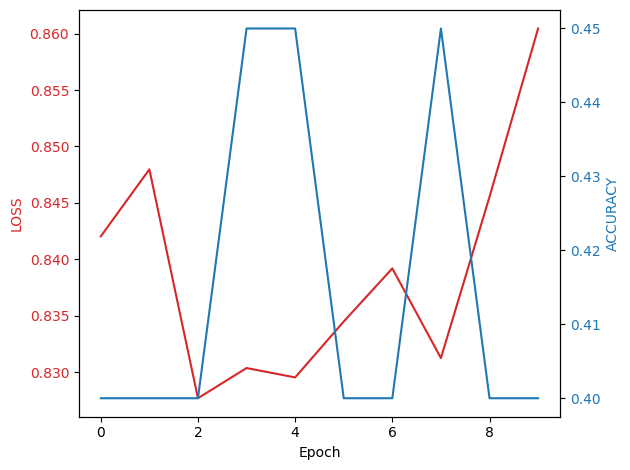

In [11]:
plot_results(loss_list, accuracy_list, save=True, plot_name='training-before-fine-tunning')

### 3.2.1 Adjust hyper-parameters

The base and maximum learning rates will be adjusted to improve the model performance:

In [22]:
cnn.update_hypams(
    base_lr=0.001,
    max_lr=0.01
)

cnn.print_hypams()

Epochs: 10
Batch size: 32
Learning rate: 1e-06
Momentum: 0.9
Lr. scheduler: True
	Base lr: 0.001
	Max lr: 0.01


In [13]:
accuracy_list, loss_list = cnn._train()

Starting training. This might take a few minutes...


  0%|                                                                                           | 0/10 [00:00<?, ?it/s]


Epoch 1 done


 10%|████████▎                                                                          | 1/10 [00:11<01:42, 11.35s/it]

Learning rate: 0.002800000000000002
Validation loss (epoch 1): 8.7609
Validation accuracy (epoch 1): 0.5000

Epoch 2 done


...

Learning rate: 0.0046
Validation loss (epoch 8): 0.4854
Validation accuracy (epoch 8): 0.9500

Epoch 9 done


 90%|██████████████████████████████████████████████████████████████████████████▋        | 9/10 [01:39<00:11, 11.05s/it]

Learning rate: 0.002800000000000002
Validation loss (epoch 9): 0.4987
Validation accuracy (epoch 9): 0.9500

Epoch 10 done


100%|██████████████████████████████████████████████████████████████████████████████████| 10/10 [01:49<00:00, 10.96s/it]

Learning rate: 0.001
Validation loss (epoch 10): 0.2416
Validation accuracy (epoch 10): 0.9500

Best accuracy: 0.95
Training finished.


After adjusting the base and mamimum learning rate of the **learning rate scheduler**, the maximum accuracy across the validation dataset improved by **+70%**

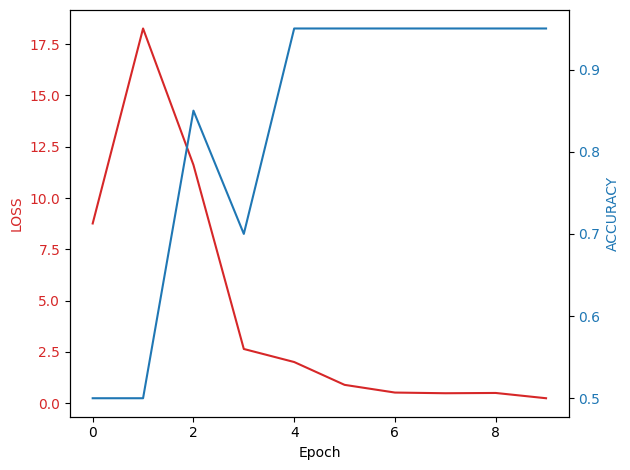

In [14]:
plot_results(loss_list, accuracy_list, save=True, plot_name='training-after-fine-tuning')

# 4. Save model

After getting posisitive results of the training phase, the best model can be saved to perform some testing.

In [18]:
cnn.save_model(src_models, name='stop-signal-classifier.pt')

Model saved at ./outputs/models


# 5. Test model

The saved model will be tested with some sample images never seen before.

Load the model:

In [20]:
cnn.load_model(path='./outputs/models/stop-signal-classifier.pt')

Successfully loaded from ./outputs/models/stop-signal-classifier.pt


Predict on sample images:

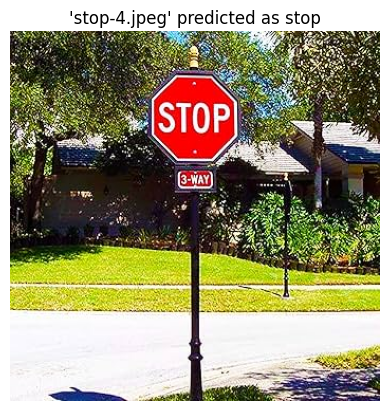

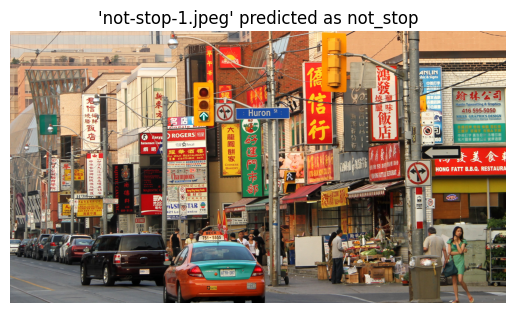

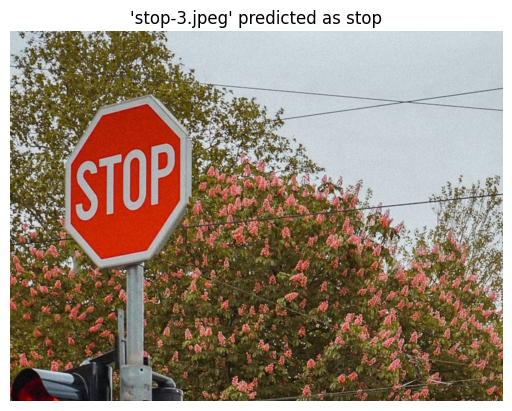

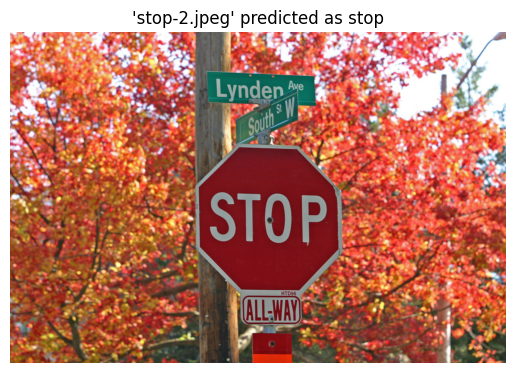

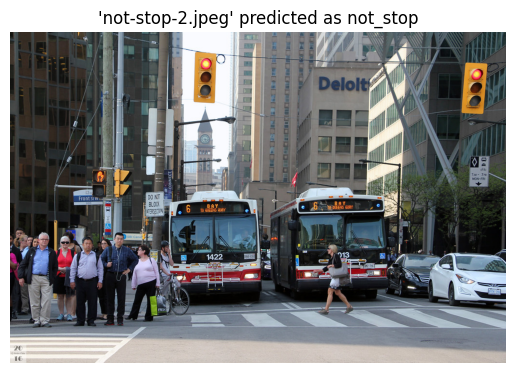

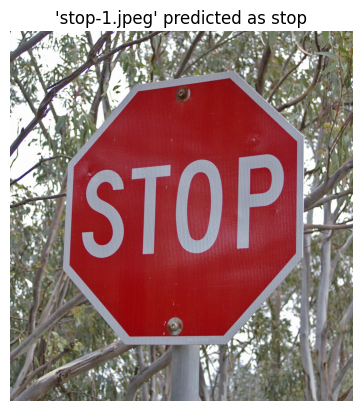

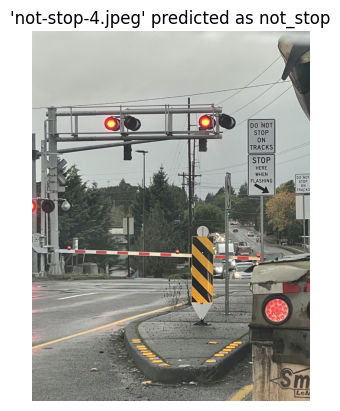

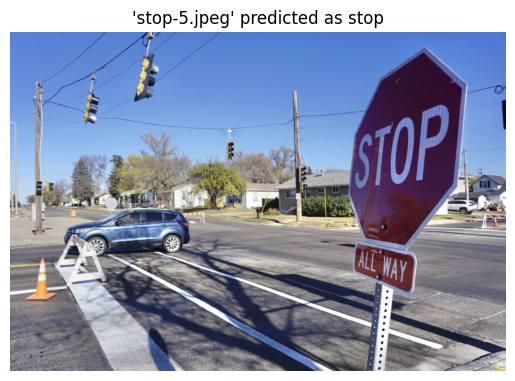

In [21]:
# Store and suffle file names
image_names = [f for f in os.listdir(src_test_images) if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))]
random.shuffle(image_names)

# Predict 
for image in image_names:
    path = os.path.join(src_test_images, image)
    # Make prediction
    _, class_ = cnn.predict(path, print_=False)
    # Show image
    _imshow(path, f"'{image}' predicted as {class_}")